In [1]:
from synapse_counting import results_plotting
import seaborn as sns
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

In [2]:
# Candidate to make the heatmap of
protein = "VCAM1"

In [3]:
# order to show the metrics and hippocampal layers

metric_order = [
    "presynapse_image_mfi", 
    "pre_staining_area_um2",
    "pre_puncta_density_per_100_um2",
    "pre_mean_puncta_size_um2",
    "postsynapse_image_mfi",
    "post_staining_area_um2",
    "post_puncta_density_per_100_um2",
    "post_mean_puncta_size_um2",
    "local_peak_colocalized_spots",
    "pearson_cor",
    "overlap_coeff",
    "overlap_um2"
    ]

vglut1_hippocampal_layer_order = [
    "CA1 SO",
    "CA1 SR",
    "CA1 SLM",
    "CA3 SO",
    "CA3 SL",
    "CA3 SR",
    "DG ML",
    "DG Hilus"
    ]

vgat_hippocampal_layer_order = [
    "CA1 SO",
    "CA1 SR",
    "CA1 SLM",
    "CA3 SO",
    "CA3 SL",
    "CA3 SR",
    "DG ML",
    "DG Hilus"
    ]

In [4]:
#reading in the VGLUT1-PSD95 data
file_path_vglut1 = "/Volumes/Intenso/image-analysis/synapse-counting/results_202512/VCAM1_VGLUT1-PSD95_lmem_analysis_results.csv"
df_vglut1 = pd.read_csv(file_path_vglut1)
df_vglut1.head(10)

,hippocampal_layer,emmean,SE,df,t.ratio,p.value,p.value.adj,analyzed_metric,analyzed_protein
0,CA1 SLM,-1.255812,0.188202,3,-6.672694,0.006863,0.021591,local_peak_colocalized_spots,VCAM1
1,CA1 SO,-1.285251,0.216564,3,-5.934739,0.009562,0.021591,local_peak_colocalized_spots,VCAM1
2,CA1 SR,-1.248157,0.409118,3,-3.050846,0.055391,0.063304,local_peak_colocalized_spots,VCAM1
3,CA3 SL,-1.902279,0.402658,3,-4.724303,0.017968,0.026125,local_peak_colocalized_spots,VCAM1
4,CA3 SO,-1.613341,0.352609,3,-4.575435,0.019593,0.026125,local_peak_colocalized_spots,VCAM1
5,CA3 SR,-1.960492,0.344950,3,-5.683405,0.010795,0.021591,local_peak_colocalized_spots,VCAM1
6,DG Hilus,-0.621442,0.369097,3,-1.683683,0.190832,0.190832,local_peak_colocalized_spots,VCAM1
7,DG ML,-1.057238,0.147339,3,-7.175542,0.005576,0.021591,local_peak_colocalized_spots,VCAM1
8,CA1 SLM,-0.061368,0.033447,3,-1.834780,0.163887,0.327775,overlap_coeff,VCAM1
9,CA1 SO,0.002276,0.037006,3,0.061512,0.954820,0.986789,overlap_coeff,VCAM1


In [10]:
# get the df for adj p values
df_vglut1_adj_p_values = df_vglut1[["hippocampal_layer", "p.value.adj", "analyzed_metric"]]
df_wide_vglut1_p_value = df_vglut1_adj_p_values.pivot(index="analyzed_metric", columns="hippocampal_layer", values="p.value.adj").reindex(metric_order)
df_wide_vglut1_p_value_ordered = df_wide_vglut1_p_value[vglut1_hippocampal_layer_order]
df_wide_vglut1_p_value_ordered.head(12)

hippocampal_layer,CA1 SO,CA1 SR,CA1 SLM,CA3 SO,CA3 SL,CA3 SR,DG ML,DG Hilus
analyzed_metric,,,,,,,,
presynapse_image_mfi,0.021730,0.021730,0.029856,0.021730,0.019046,0.012272,0.087884,0.043933
pre_staining_area_um2,0.407991,0.407991,0.575582,0.600572,0.600572,0.575582,0.407991,0.601289
pre_puncta_density_per_100_um2,0.525533,0.525533,0.568507,0.877508,0.987702,0.678800,0.145412,0.877508
pre_mean_puncta_size_um2,0.544130,0.544130,0.694325,0.267629,0.420704,0.544130,0.538701,0.544130
postsynapse_image_mfi,0.002343,0.061101,0.035000,0.353047,0.061101,0.061101,0.061101,0.352301
post_staining_area_um2,0.284154,0.284154,0.284154,0.826588,0.731537,0.153535,0.826588,0.153535
post_puncta_density_per_100_um2,0.233015,0.203027,0.233015,0.833646,0.725720,0.129774,0.725720,0.129774
post_mean_puncta_size_um2,0.888965,0.366681,0.701240,0.888965,0.888965,0.701240,0.701240,0.701240
local_peak_colocalized_spots,0.021591,0.063304,0.021591,0.026125,0.026125,0.021591,0.021591,0.190832


In [6]:
# get the df for log2 fold change
df_vglut1_log2_fc = df_vglut1[["hippocampal_layer", "emmean", "analyzed_metric"]]
df_wide_vglut1_log2_fc = df_vglut1_log2_fc.pivot(index="analyzed_metric", columns="hippocampal_layer", values="emmean").reindex(metric_order)
df_wide_vglut1_log2_fc_ordered = df_wide_vglut1_log2_fc[vglut1_hippocampal_layer_order]
df_wide_vglut1_log2_fc_ordered.head(10)

hippocampal_layer,CA1 SO,CA1 SR,CA1 SLM,CA3 SO,CA3 SL,CA3 SR,DG ML,DG Hilus
analyzed_metric,,,,,,,,
presynapse_image_mfi,-0.548114,-0.551012,-0.389343,-0.558662,-0.672770,-0.629933,-0.233465,-0.312818
pre_staining_area_um2,-0.070607,-0.300676,-0.081423,-0.032753,-0.041173,-0.199742,-0.277209,-0.016982
pre_puncta_density_per_100_um2,-0.042919,-0.272335,-0.071731,0.021518,0.000974,-0.170268,-0.180382,0.010275
pre_mean_puncta_size_um2,-0.027688,-0.028342,-0.009691,-0.054271,-0.042147,-0.029474,-0.096826,-0.027257
postsynapse_image_mfi,-0.159591,-0.114277,-0.187002,-0.115770,-0.201909,-0.227641,-0.093527,-0.078975
post_staining_area_um2,-0.088050,-0.081442,-0.140018,0.028026,-0.045061,0.154673,-0.009896,-0.322655
post_puncta_density_per_100_um2,-0.091786,-0.099987,-0.124858,0.020575,-0.040200,0.161526,-0.021281,-0.314152
post_mean_puncta_size_um2,0.003736,0.018546,-0.015161,0.007451,-0.004862,-0.006853,0.011385,-0.008503
local_peak_colocalized_spots,-1.285251,-1.248157,-1.255812,-1.613341,-1.902279,-1.960492,-1.057238,-0.621442


In [ ]:
# reading in the VGAT-GEPH dataset
vgat_results_file = f"/Volumes/KINGSTON/data/phd/image-analysis/synapse-counting/{protein}/{protein}_VGAT-GEPH_lmem_analysis_results.csv"
df_vgat = pd.read_csv(vgat_results_file)
df_vgat.head(10)

In [ ]:
# get the df with adj pvalues
df_vgat_adj_p_values = df_vgat[["hippocampal_layer", "p.value.adj", "analyzed_metric"]]
df_wide_vgat_p_value = df_vgat_adj_p_values.pivot(index="analyzed_metric", columns="hippocampal_layer", values="p.value.adj").reindex(metric_order)
df_wide_vgat_p_value_ordered = df_wide_vgat_p_value[vglut1_hippocampal_layer_order]
df_wide_vgat_p_value_ordered.head(10)

In [ ]:
# get the df with log2 fold change
df_vgat_adj_log2_fc = df_vgat[["hippocampal_layer", "emmean", "analyzed_metric"]]
df_wide_vgat_log2_fc = df_vgat_adj_log2_fc.pivot(index="analyzed_metric", columns="hippocampal_layer", values="emmean").reindex(metric_order)
df_wide_vgat_log2_fc_ordered = df_wide_vgat_log2_fc[vglut1_hippocampal_layer_order]
df_wide_vgat_log2_fc_ordered.head(10)

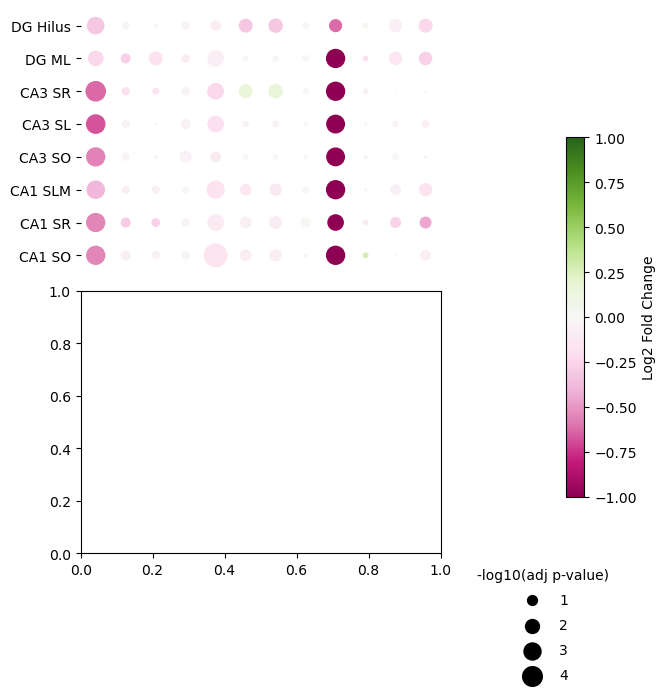

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.colors import Normalize

# Set up the figure
fig = plt.figure(figsize=(6.5, 8))

# Create a grid for the main plots and the legend
gs = fig.add_gridspec(3, 2, width_ratios=[3, 1], height_ratios=[1, 1, 0.2], hspace=0.1, wspace=0.1)

# Data and parameters for each plot
data_sets = [
    #(df_wide_vgat_p_value_ordered, df_wide_vgat_log2_fc_ordered, vgat_hippocampal_layer_order),
    (df_wide_vglut1_p_value_ordered, df_wide_vglut1_log2_fc_ordered, vglut1_hippocampal_layer_order)
]
titles = ['VGAT', 'VGLUT1']

# Create subplots for the main plots
axes = [fig.add_subplot(gs[i, 0]) for i in range(2)]

for i, (ax, (df_p_value, df_log2_fc, hippocampal_layer_order)) in enumerate(zip(axes, data_sets)):
    # Remove spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)

    # Flatten the data
    x_vals = np.repeat(range(len(metric_order)), len(hippocampal_layer_order))
    y_vals = np.tile(range(len(hippocampal_layer_order)), len(metric_order))
    sizes = df_p_value.values.flatten()
    sizes_log = -np.log10(sizes) * 100
    colors = df_log2_fc.values.flatten()

    # Apply cutoff
    cutoff = 0
    sizes_log[sizes_log < (cutoff * 100)] = 3

    # Create scatter plot
    norm = Normalize(vmin=-1, vmax=1)
    scatter = ax.scatter(x_vals, y_vals, s=sizes_log, c=colors, cmap='PiYG', norm=norm)
    
    # Adjust x and y limits to avoid cutting off points
    ax.set_xlim(-0.5, len(metric_order) - 0.5)
    ax.set_ylim(-0.5, len(hippocampal_layer_order) - 0.5)
    
    # Set y ticks for each plot
    ax.set_yticks(range(len(hippocampal_layer_order)))
    ax.set_yticklabels(hippocampal_layer_order)

    # Only set x ticks for the bottom plot
    if i == 2:  # Bottom plot
        ax.set_xticks(range(len(metric_order)))
        ax.set_xticklabels(metric_order, rotation=90)
    else:
        ax.set_xticks([])

    # Set title for each subplot
    #ax.set_title(titles[i], y=1.0, pad=-14)

# Create a subplot for the legends
legend_ax = fig.add_subplot(gs[:, 1])
legend_ax.axis('off')

# Add a colorbar
cbar = fig.colorbar(scatter, ax=legend_ax, shrink=0.8, aspect=20, pad=0.05)
cbar.set_label("Log2 Fold Change")

# Create a legend for dot sizes
size_legend_labels = [1, 2, 3, 4]
size_legend = [plt.scatter([], [], s=size*50, edgecolor='black', facecolor='black') for size in size_legend_labels]
legend_ax.legend(size_legend, [f'{label}' for label in size_legend_labels],
                 title='-log10(adj p-value)', loc='center left', bbox_to_anchor=(0, 0),
                 handletextpad=1, labelspacing=0.8, frameon=False)



#plt.savefig(f"/Volumes/KINGSTON/data/phd/image-analysis/synapse-counting/{protein}_dotplot", dpi=600, bbox_inches = "tight")
#plt.tight_layout()
plt.show()